# All computations

In [1]:
import numpy as np
import pandas as pd
import os

import sys
sys.path.append('..')

## Dataframe computations

In [2]:
from surface_functions import compute_surface_variance, compute_surface_roughness, compute_heightdifference_correlations
from surface_functions import compute_structure_factor, compute_phase_covariance
from fluctuation_functions import compute_rescaled_phases_at_index

### 2. Roughness

In [3]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        roughness_list = []  # used to compute per-sim roughness
        variance_list = []   # used to compute per-sim variance
        datapoint_list = []

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            variance = np.asarray(compute_surface_variance(phases), dtype=float)
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)

            variance_list.append(variance)
            roughness_list.append(roughness)
            datapoint_list.append(len(roughness))

        # Avoid chained-assignment issues
        df = df.copy()
        df["variance"] = variance_list
        df["roughness"] = roughness_list
        df["datapoints"] = datapoint_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)

            variance_arrays = [np.asarray(r, dtype=float) for r in group["variance"]]
            mean_roughness2 = np.sqrt(np.mean(np.stack(variance_arrays, axis=0), axis=0))

            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{M}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_roughness": mean_roughness,
                    "mean_roughness2": mean_roughness2,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [4]:
# Note: we start from scratch the average DataFrame (each time this code is run)
avg_df = pd.DataFrame()
avg_df_path = "../Simulations_1D/average_simulations.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    avg_df.to_pickle(avg_df_path)
    print(f"Saved average simulations ({len(df)}) to:", avg_df_path)

Saved average simulations (17499) to: Simulations/average_simulations.pkl


In [5]:
avg_df[(avg_df["K"] == 40) & (avg_df["T"] == 20000)]

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2
avg_id,,,,,,,,,,
Columnar_delta0_L125_K40.0_T20000_M3000,Columnar,0.000000,0,40.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.11461032003170477, 0.1569503858630901,...","[0.0, 0.11770856603007997, 0.16237676956316305..."
Columnar_delta0_L250_K40.0_T20000_M3000,Columnar,0.000000,0,40.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.12222002382088445, 0.17058895747819514...","[0.0, 0.123841119916426, 0.1734795250608667, 0..."
Columnar_delta0_L500_K40.0_T20000_M3000,Columnar,0.000000,0,40.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.1258834998158019, 0.17711769638802907,...","[0.0, 0.1266989469781417, 0.17860927908329094,..."
Columnar_delta0_L1000_K40.0_T20000_M8362,Columnar,0.000000,0,40.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",8362,20000,"[0.0, 0.12770683115079906, 0.18033726902189454...","[0.0, 0.128123927460464, 0.1810916949712311, 0..."
Columnar_deltaatan5_L125_K40.0_T20000_M2999,Columnar,1.373401,atan5,40.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",2999,20000,"[0.0, 0.18420179567662112, 0.25530045465918827...","[0.0, 0.18622031268713773, 0.25899181404794874..."
Columnar_deltaatan5_L250_K40.0_T20000_M3000,Columnar,1.373401,atan5,40.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.18873564913862148, 0.2637951097933861,...","[0.0, 0.18972890958847194, 0.2656174631525605,..."
Columnar_deltaatan5_L500_K40.0_T20000_M3000,Columnar,1.373401,atan5,40.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",3000,20000,"[0.0, 0.19145951500897088, 0.26844303429675004...","[0.0, 0.19195445882449544, 0.26933612511008787..."
Columnar_deltaatan5_L1000_K40.0_T20000_M8000,Columnar,1.373401,atan5,40.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",8000,20000,"[0.0, 0.19257094555552245, 0.2704151796116424,...","[0.0, 0.1928261137365568, 0.27088733058570574,..."


### 3. Height-height correlations (takes the longest, ~40min)

In [6]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        heightheight_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            heightheight = np.asarray(compute_heightdifference_correlations(phases), dtype=float)

            heightheight_list.append(heightheight)

        # Avoid chained-assignment issues
        df = df.copy()
        df["heightheight"] = heightheight_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE HEIGHT-HEIGHT CORRELATION PER (K, L, T) ##
        # group by K, L, T and compute mean height-height correlation for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            heightheight_arrays = [np.asarray(r, dtype=float) for r in group["heightheight"]]
            mean_heightheight = np.mean(np.stack(heightheight_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_heightheight": mean_heightheight,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [7]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_heightheight"] = new_avg["mean_heightheight"]

avg_df.to_pickle(avg_df_path)

### 4. Structure Factor

In [8]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        structurefactor_list = []  # used to compute per-sim roughness

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            structurefactor = np.asarray(compute_structure_factor(phases), dtype=float)

            structurefactor_list.append(structurefactor)

        # Avoid chained-assignment issues
        df = df.copy()
        df["structurefactor"] = structurefactor_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE STRUCTURE FACTOR PER (K, L, T) ##
        # group by K, L, T and compute mean structure factor for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            structurefactor_arrays = [np.asarray(r, dtype=float) for r in group["structurefactor"]]
            mean_structurefactor = np.mean(np.stack(structurefactor_arrays, axis=0), axis=0)
            
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_structurefactor": mean_structurefactor,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [9]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_structurefactor"] = new_avg["mean_structurefactor"]

avg_df.to_pickle(avg_df_path)

### 5. Phase covariance (takes long as well)

In [10]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        hprodh_average_list = []  # used to compute per-sim \overline{h(x,t)h(x+r,t)}
        h_average_list = []  # used to compute per-sim height \overline{h(x,t)}

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            hprodh_average, h_average = compute_phase_covariance(phases)

            hprodh_average_list.append(hprodh_average)
            h_average_list.append(h_average)

        # Avoid chained-assignment issues
        df = df.copy()
        df["hprodh_average"] = hprodh_average_list
        df["h_average"] = h_average_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE PHASE-COVARIANCE PER (K, L, T) ##
        # group by K, L, T and compute mean phase-covariance for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            hprodh_average_arrays = [np.asarray(r, dtype=float) for r in group["hprodh_average"]]
            h_average_arrays = [np.asarray(r, dtype=float) for r in group["h_average"]]

            # Term 1: < overline{φ(x, t) φ(x + r, t)} >
            term1 = np.mean(np.stack(hprodh_average_arrays, axis=0), axis=0)

            # Term 2: ( < overline{φ}(x, t) > )^2
            # Note: h_average_arrays has shape (M, Nt), so we mean over axis 0 to get (Nt,)
            term2 = np.mean(np.stack(h_average_arrays, axis=0), axis=0)**2

            # We need to broadcast term2 (Nt,) to match term1 (Nt, N)
            # Since term2 varies only with time, we subtract it from every 'r' column
            mean_phasecovariance = term1 - term2[:, np.newaxis]

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "mean_phasecovariance": mean_phasecovariance,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [11]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "mean_phasecovariance"] = new_avg["mean_phasecovariance"]

avg_df.to_pickle(avg_df_path)

### 6. Phase fluctuations

Computing the phase fluctuations properly requires knowing beta, and the saturation time to remain in the growth regime.

In [5]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": alpha_dict["Columnar"]["EW"]/z_dict["Columnar"]["EW"], "KPZ": alpha_dict["Columnar"]["KPZ"]/z_dict["Columnar"]["KPZ"]}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

# Adjustment to the saturation time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

In [6]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_1D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        beta = beta_dict[typenoise][delta_to_label[deltaname]]
        z = z_dict[typenoise][delta_to_label[deltaname]]

        ## AVERAGE FLUCTUATION STATISTICS PER (K, L, T) ##
        # group by K, L, T and compute fluctuation statistics for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):
            
            # if K_val not in Ks or T_val != T or L_val != L:
            #     continue
            
            t_cross = tx[typenoise][delta_to_label[deltaname]] * (L_val ** z)
            
            per_seed_varphis = []
            for _, row in group.iterrows():
                t = np.asarray(row["t"])
                phases = np.asarray(row["phases"])

                t0_idx = int(np.argmin(np.abs(t - 50)))-2 # optional, where to start.

                for ti_idx in range(t0_idx + 1, len(t)):
                    if t[ti_idx] < t_cross:
                        v = compute_rescaled_phases_at_index(phases, t, t0_idx, ti_idx, beta=beta)
                        per_seed_varphis.append(v)

            varphis_full = np.ravel(per_seed_varphis)
            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{len(group)}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "varphis_full": varphis_full,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [7]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
avg_df.loc[new_avg.index, "varphis_full"] = new_avg["varphis_full"]

avg_df.to_pickle(avg_df_path)

## Inspection of the computed quantities

In [8]:
avg_df_path = "../Simulations_1D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [9]:
df_TimeDep = avg_df[(avg_df["K"] == 1) & (avg_df["T"] == 20000)]
df_Columnar = avg_df[(avg_df["K"] == 40) & (avg_df["T"] == 20000)]

print("TimeDep", df_TimeDep[["deltaname", "L", "M"]])
print()
print("Columnar", df_Columnar[["deltaname", "L", "M"]])

TimeDep                                            deltaname     L     M
avg_id                                                          
TimeDep_delta0_L125_K1.0_T20000_M3000              0   125  3000
TimeDep_delta0_L250_K1.0_T20000_M3000              0   250  3000
TimeDep_delta0_L500_K1.0_T20000_M3000              0   500  3000
TimeDep_delta0_L1000_K1.0_T20000_M5991             0  1000  5991
TimeDep_deltaatan5_L125_K1.0_T20000_M3000      atan5   125  3000
TimeDep_deltaatan5_L250_K1.0_T20000_M3000      atan5   250  3000
TimeDep_deltaatan5_L500_K1.0_T20000_M2927      atan5   500  2927
TimeDep_deltaatan5_L1000_K1.0_T20000_M5637     atan5  1000  5637

Columnar                                              deltaname     L     M
avg_id                                                            
Columnar_delta0_L125_K40.0_T20000_M3000              0   125  3000
Columnar_delta0_L250_K40.0_T20000_M3000              0   250  3000
Columnar_delta0_L500_K40.0_T20000_M3000              0   500  30

## Plotting results

In [10]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

from plotting_helpers_evolution import plot_roughness_evolution, plot_heightdifference_evolution, plot_structurefactor_evolution, plot_phasecovariance_evolution
from plotting_helpers_collapse import plot_roughness_collapse, plot_heightdifference_collapse, plot_structurefactor_collapse, plot_phasecovariance_collapse
from fluctuation_functions import plot_fluctuations_pdf

In [11]:
T = 20000
L = 1000

In [12]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

### 2. Roughness

# TimeDep
## 0
	 $t_\star$(125) = 156.25.
	 $t_\star$(250) = 625.0.
	 $t_\star$(500) = 2500.0.
	 $t_\star$(1000) = 10000.0.
## atan5
	 $t_\star$(125) = 139.75424859373686.
	 $t_\star$(250) = 395.28470752104744.
	 $t_\star$(500) = 1118.033988749895.
	 $t_\star$(1000) = 3162.2776601683795.
# Columnar
## 0
	 $t_\star$(125) = 10.416666666666666.
	 $t_\star$(250) = 41.666666666666664.
	 $t_\star$(500) = 166.66666666666666.
	 $t_\star$(1000) = 666.6666666666666.
## atan5
	 $t_\star$(125) = 8.886027044968978.
	 $t_\star$(250) = 22.80911447191511.
	 $t_\star$(500) = 58.54761642746535.
	 $t_\star$(1000) = 150.2830543271767.


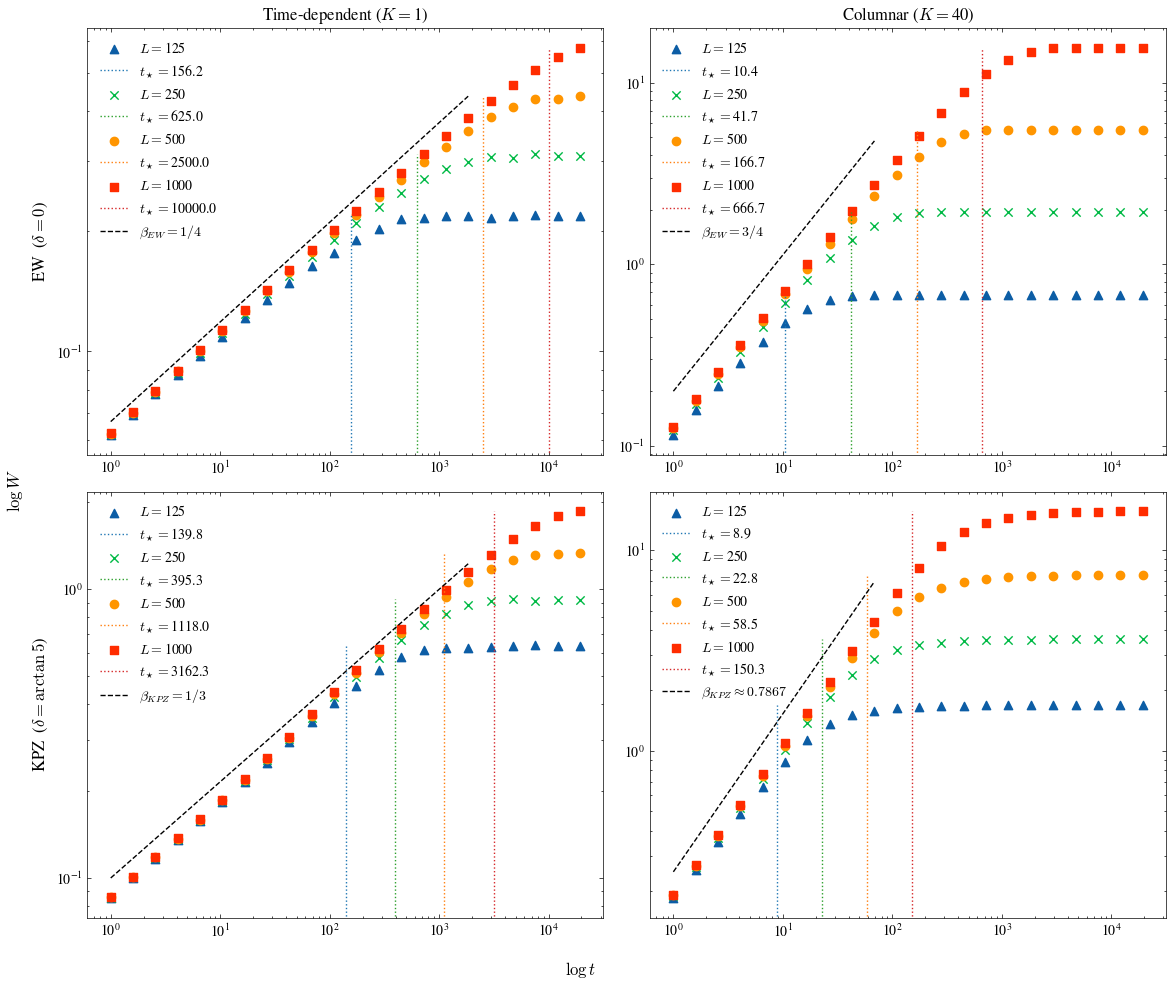

In [7]:
plot_roughness_evolution(avg_df, T, tx, save=True)

#### Family-Vicsek collapse

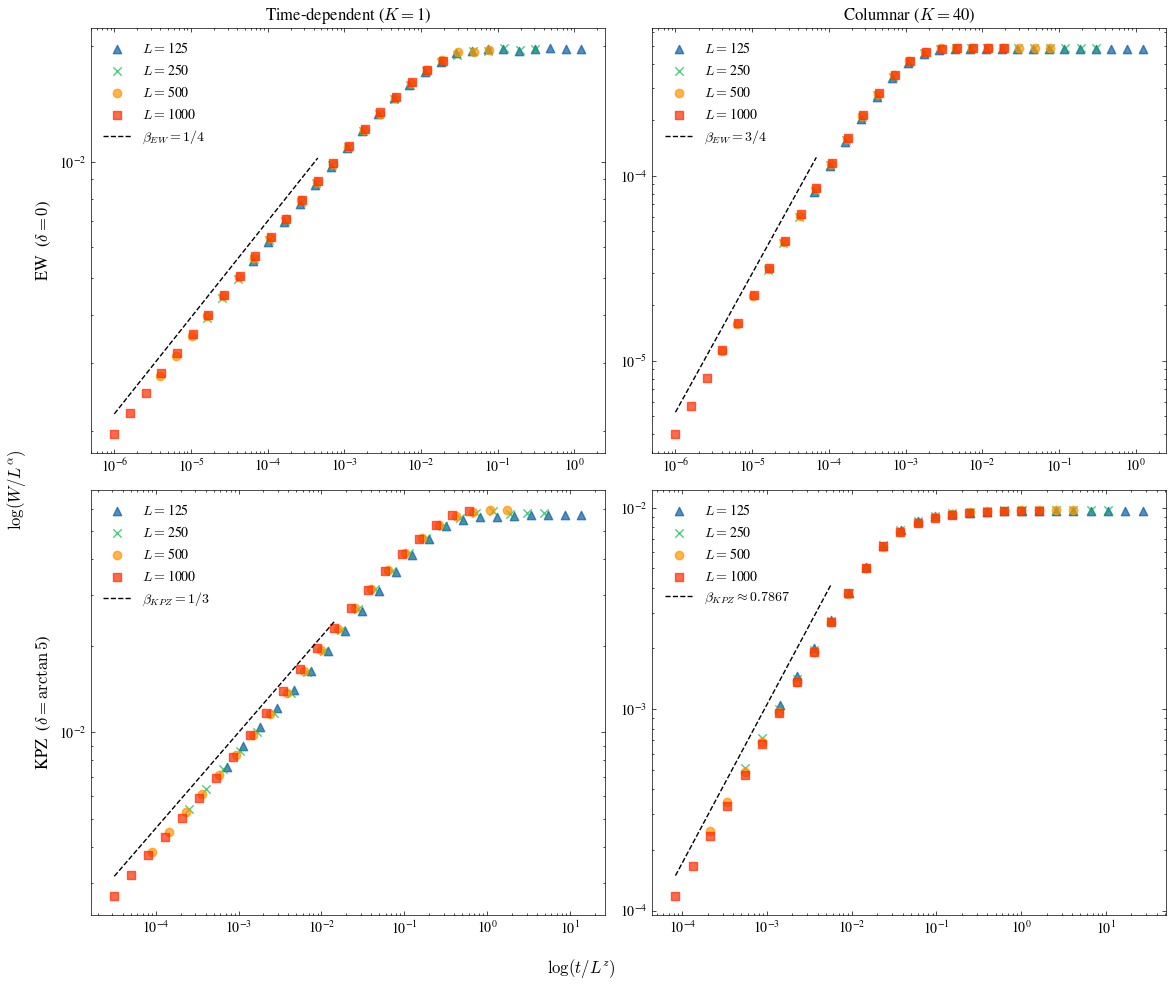

In [8]:
plot_roughness_collapse(avg_df, T, tx, save=True)

### 3. Height-difference correlations

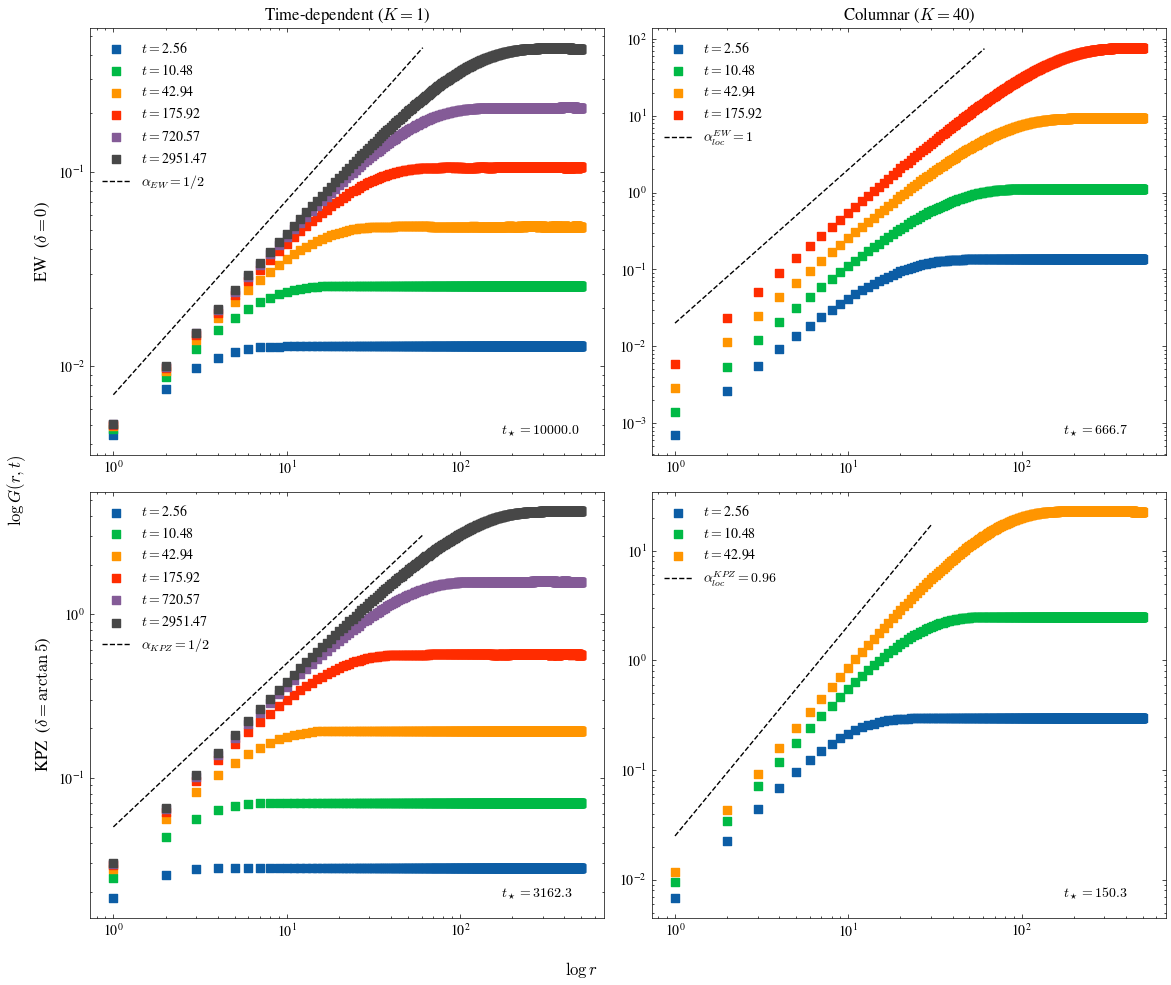

In [9]:
plot_heightdifference_evolution(avg_df, L, T, tx, save=True)

#### Family-Vicsek collapse

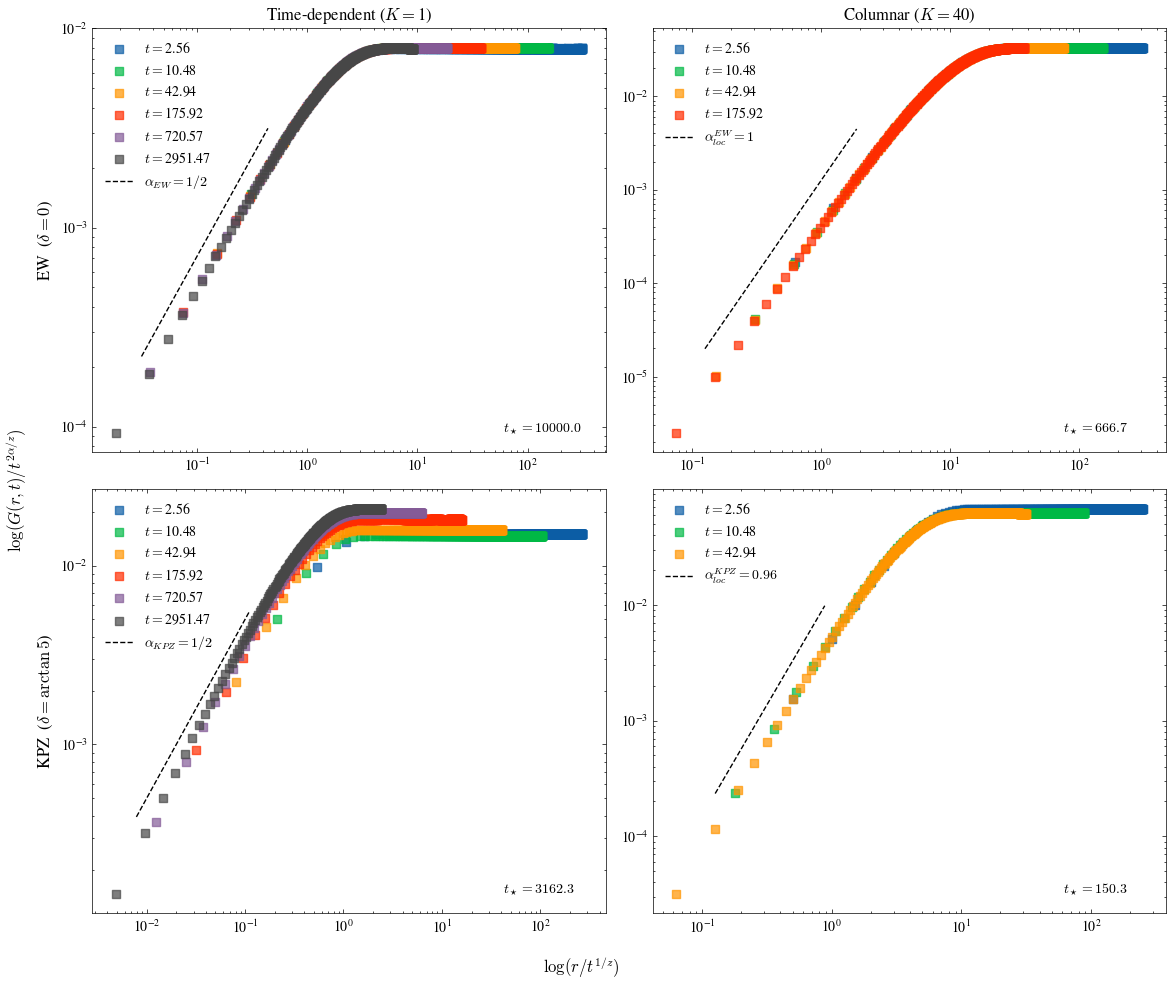

In [10]:
plot_heightdifference_collapse(avg_df, L, T, tx, save=True)

### 4. Structure factor

/mnt/datos/gonzalo/Projects/RoughKuramoto/Notebooks_1D/plotting_helpers_evolution.py:248: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1,0].set_ylim(0,1e3)
/mnt/datos/gonzalo/Projects/RoughKuramoto/Notebooks_1D/plotting_helpers_evolution.py:249: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax[1,1].set_ylim(0,1e4)
/mnt/datos/gonzalo/Projects/RoughKuramoto/Notebooks_1D/plotting_helpers_evolution.py:184: RuntimeWarning: divide by zero encountered in divide
  S_phi = ((2 * np.pi)**d * 2 * sigma / (nu**2 * k**4)) * (1 - np.exp(- nu * k**2 * t))**2
/mnt/datos/gonzalo/Projects/RoughKuramoto/Notebooks_1D/plotting_helpers_evolution.py:184: RuntimeWarning: invalid value encountered in multiply
  S_phi = ((2 * np.pi)**d * 2 * sigma / (nu**2 * k**4)) * (1 - np.exp(- nu * k**2 * t))**2


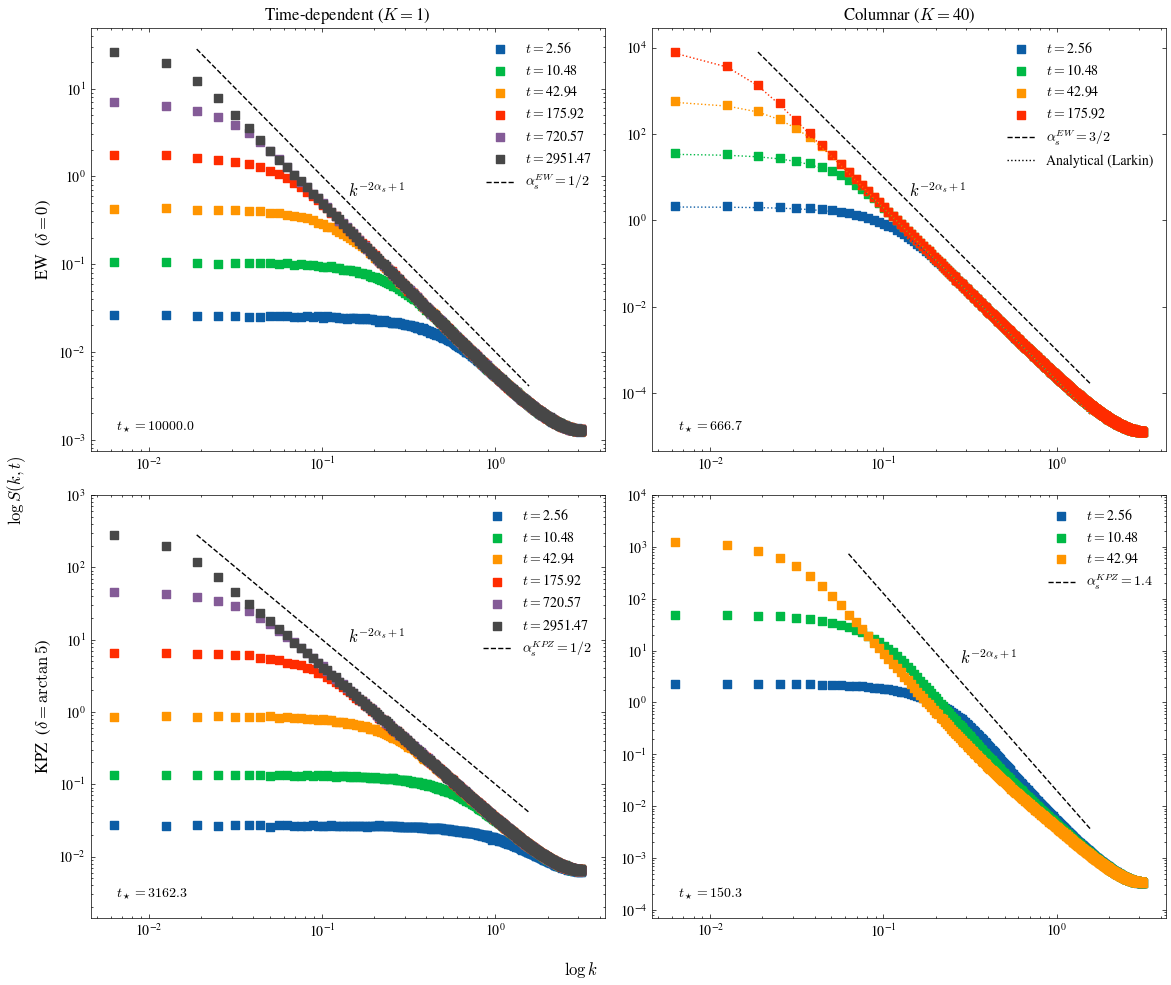

In [11]:
plot_structurefactor_evolution(avg_df, L, T, tx, analytical=True, sigma=1/40, save=True)

#### Family-Vicsek collapse

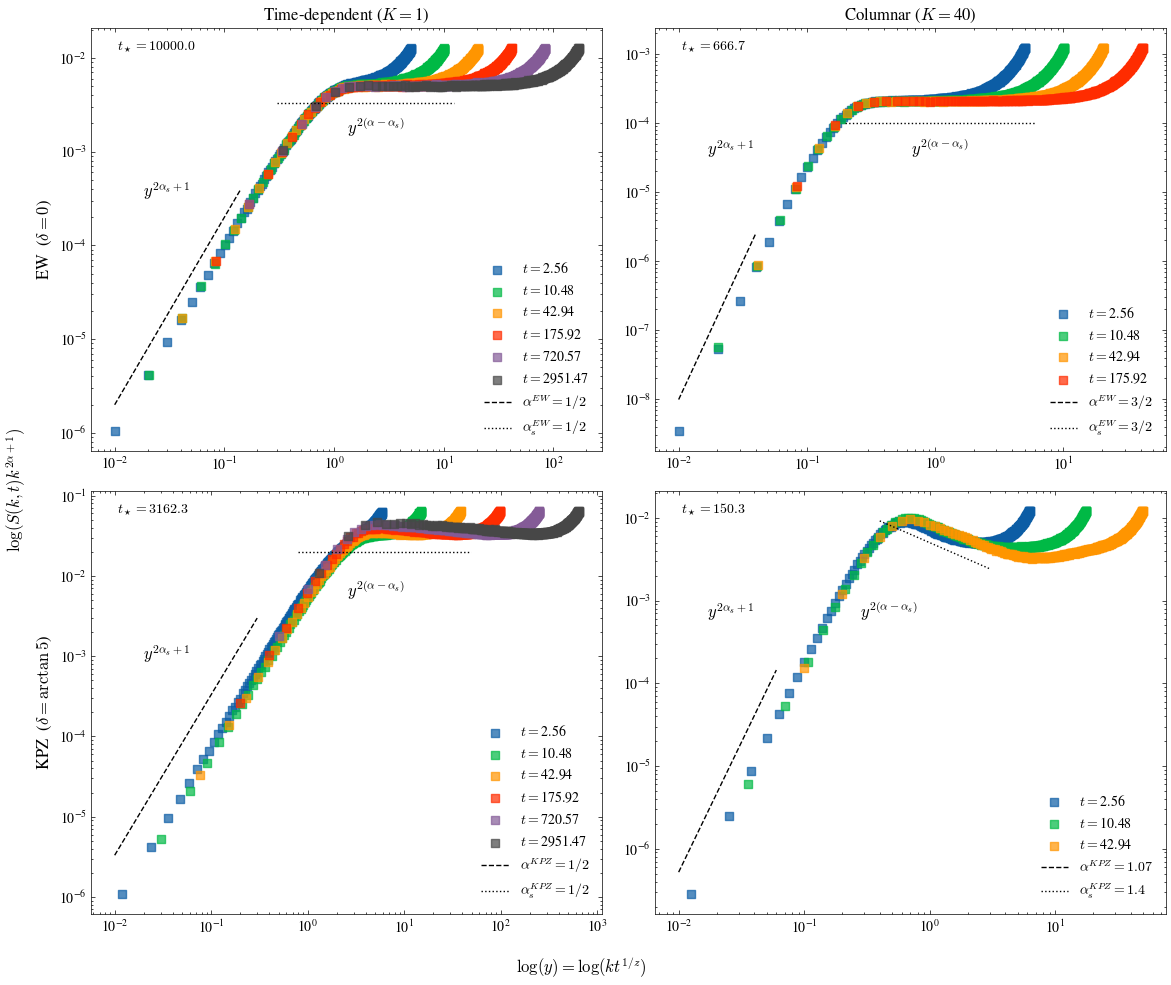

In [12]:
plot_structurefactor_collapse(avg_df, L, T, tx, save=True)

### 5. Phase covariance

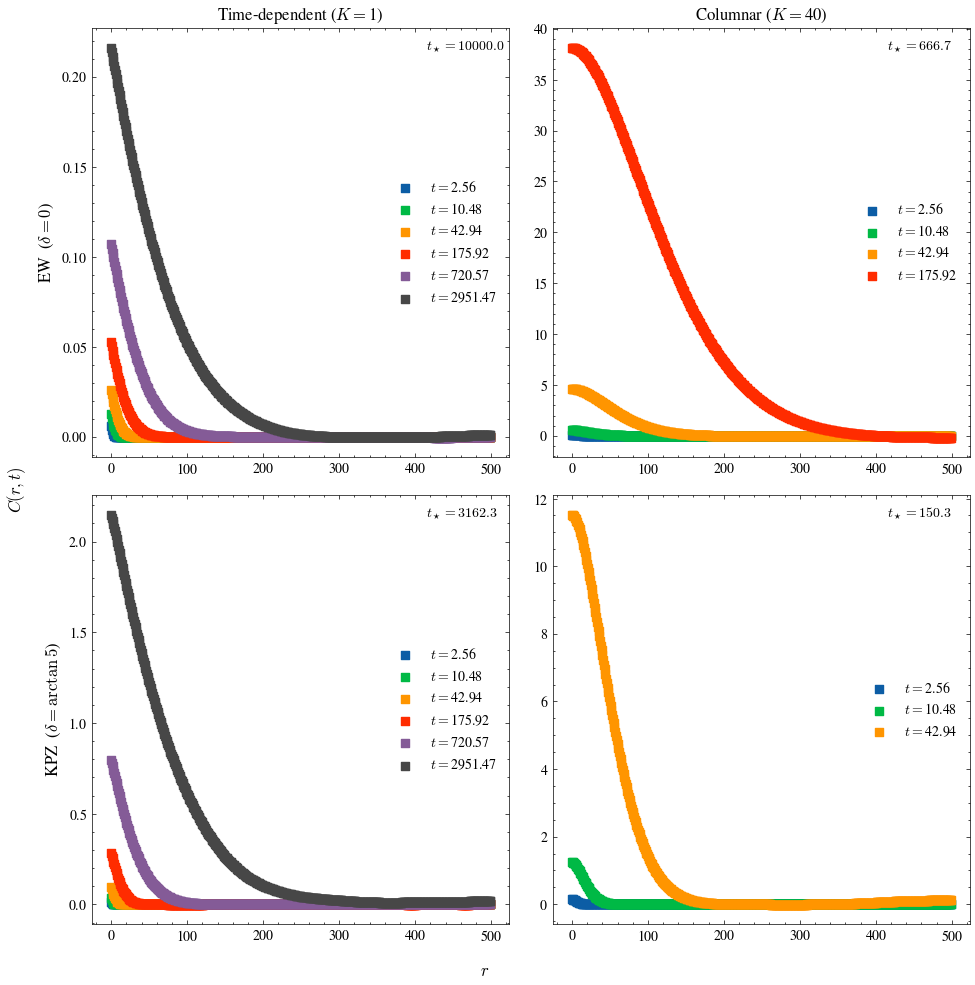

In [13]:
plot_phasecovariance_evolution(avg_df, L, T, tx, Ks=[1,40], save=True)

#### Family-Vicsek collapse

/mnt/datos/gonzalo/Projects/RoughKuramoto/Notebooks_1D/plotting_helpers_collapse.py:353: IntegrationWarning: The maximum number of subdivisions (300) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(lambda kappa: np.cos(2*np.pi*kappa*x) * g(kappa), 0.0, np.inf,


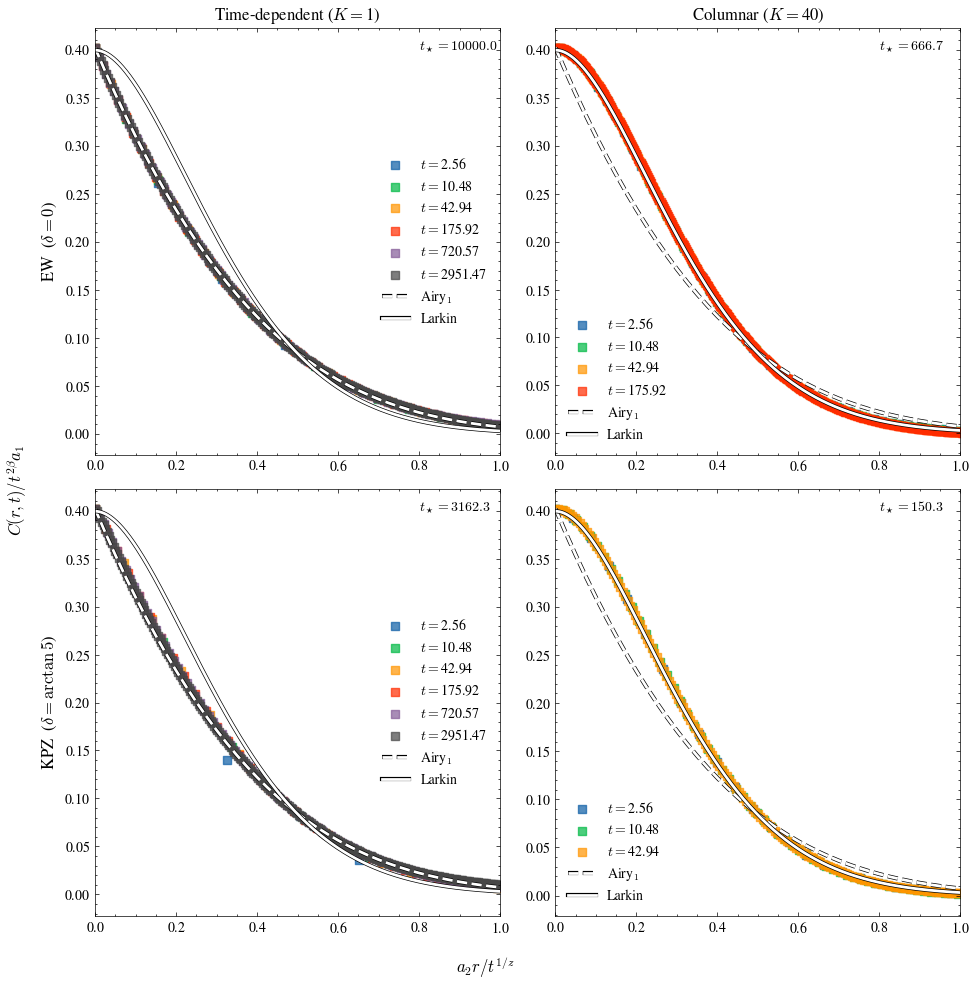

In [14]:
_, _ = plot_phasecovariance_collapse(avg_df, L, T, tx, Ks=[1,40], save=True)

### 6. Phase fluctuations statistics

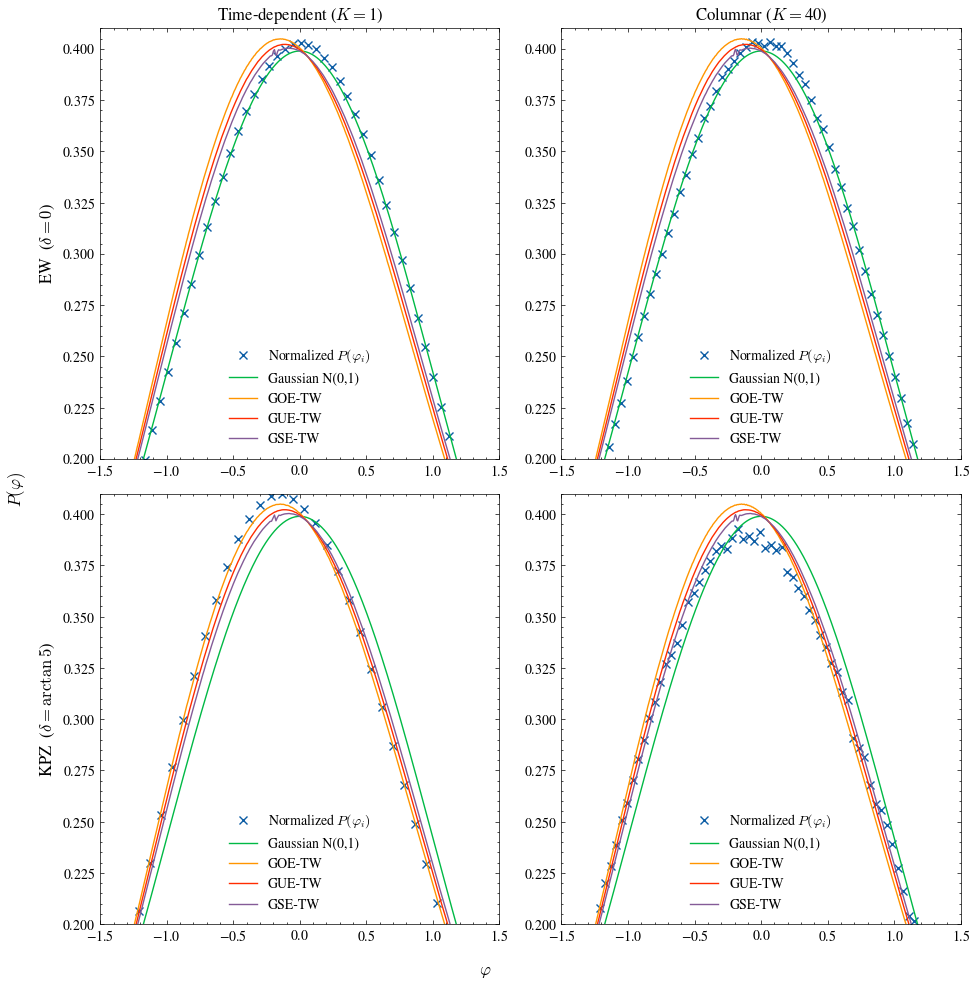

In [15]:
plot_fluctuations_pdf(avg_df, L, T, tx, Ks=[1,40], save=True)